In [2]:
import sys, os

root_dir = os.path.abspath(os.path.join(os.getcwd(), "../../"))
if root_dir not in sys.path:
    sys.path.append(root_dir)

In [3]:
from utils.data import get_project_root

data_dir = get_project_root() / "data"

data_dir

WindowsPath('D:/INGENIERIA FISICA/9no SEMESTRE/thesis-mayan-ai/data')

In [4]:
import pandas as pd

speakers_df = pd.read_csv(str(data_dir / "speakers_metadata.tsv"), sep="\t")

speakers_df

,id,edad,sexo
0,spk_001,24,M
1,spk_002,25,F
2,spk_003,45,F
3,spk_004,50,M
4,spk_005,36,M


In [5]:
chosen_spkr_id = "spk_001"
file_name = f"{chosen_spkr_id}_utt_0010"
audio_name = f"{file_name}.wav"
lib_name = f"{file_name}.lab"

dir_path = data_dir / "audios" / chosen_spkr_id
audio_path = dir_path / audio_name
lib_path = dir_path / lib_name
audio_path, lib_path

(WindowsPath('D:/INGENIERIA FISICA/9no SEMESTRE/thesis-mayan-ai/data/audios/spk_001/spk_001_utt_0010.wav'),
 WindowsPath('D:/INGENIERIA FISICA/9no SEMESTRE/thesis-mayan-ai/data/audios/spk_001/spk_001_utt_0010.lab'))

In [6]:
with open(lib_path, "r") as file:
    utterance = file.read()

utterance

"Ba'ax ka beetik"

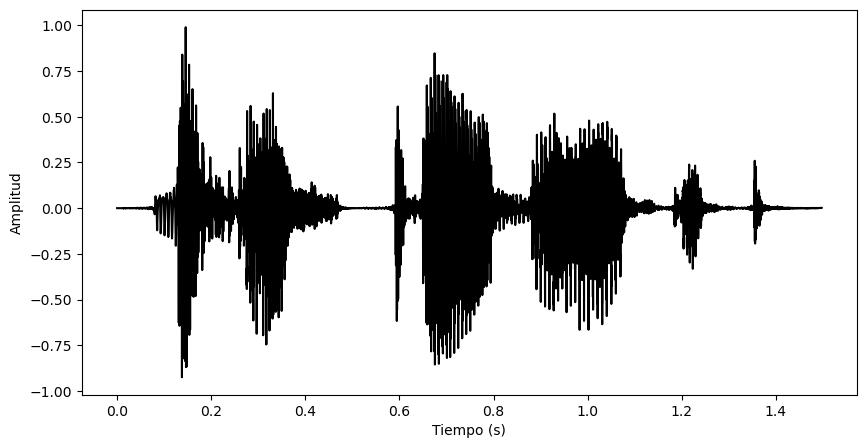

In [7]:
import parselmouth
import matplotlib.pyplot as plt
from utils.audio import display_audio

snd = parselmouth.Sound(str(audio_path))
plt.figure(figsize=(10,5))
plt.plot(snd.xs(), snd.values.T, color="black")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.show()

display_audio(snd)

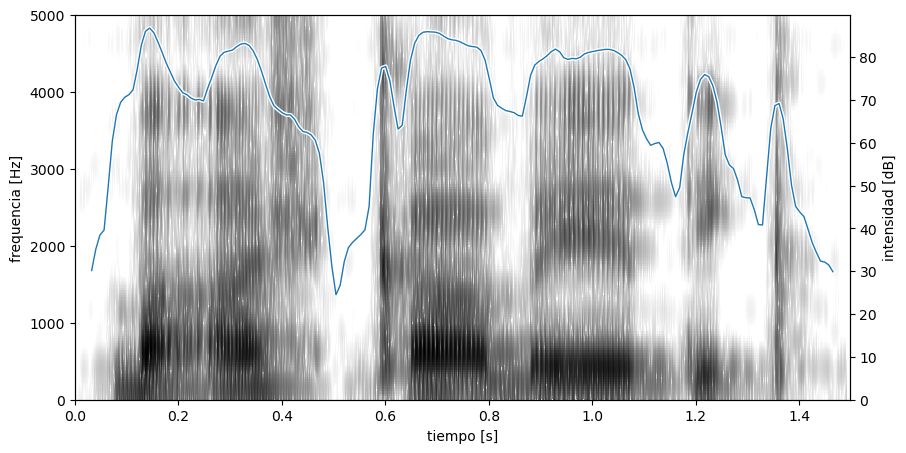

In [ ]:
import numpy as np

def draw_spectrogram(spectrogram, dynamic_range=70):
    X, Y = spectrogram.x_grid(), spectrogram.y_grid()
    sg_db = 10 * np.log10(spectrogram.values)
    plt.pcolormesh(X, Y, sg_db, vmin=sg_db.max() - dynamic_range, cmap='Greys')
    plt.ylim([spectrogram.ymin, spectrogram.ymax])
    plt.xlabel("tiempo [s]")
    plt.ylabel("frequencia [Hz]")

def draw_intensity(intensity):
    plt.plot(intensity.xs(), intensity.values.T, linewidth=3, color='w')
    plt.plot(intensity.xs(), intensity.values.T, linewidth=1)
    plt.grid(False)
    plt.ylim(0)
    plt.ylabel("intensidad [dB]")

intensity = snd.to_intensity()
spectrogram = snd.to_spectrogram()
plt.figure(figsize=(10,5))
draw_spectrogram(spectrogram, dynamic_range=80)
plt.twinx()
draw_intensity(intensity)
plt.xlim([snd.xmin, snd.xmax])
plt.show()
display_audio(snd)

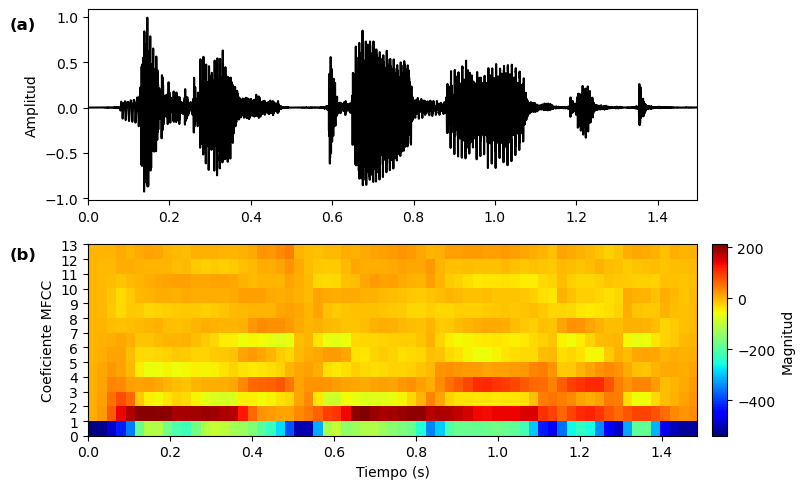

Forma del MFCC: (13, 65)
Duración estimada: 1.486077097505669 segundos


In [70]:
import librosa
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

y, sr = librosa.load(str(audio_path))

mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
times = librosa.frames_to_time(np.arange(mfcc.shape[1]), sr=sr)

fig = plt.figure(figsize=(8,5))

gs = gridspec.GridSpec(2, 2, figure=fig, width_ratios=[2,.05])

ax_wave = fig.add_subplot(gs[0,0])
ax_mfcc = fig.add_subplot(gs[1,0])
ax_cbar = fig.add_subplot(gs[1,1])

# Plot the wave
ax_wave.plot(snd.xs(), snd.values.T, color="black")
ax_wave.set_ylabel("Amplitud")
ax_wave.set_xlim(0, snd.get_total_duration())

# Plot the MFCC
im = ax_mfcc.imshow(
    mfcc,
    aspect='auto',
    origin='lower',
    extent=[times[0], times[-1], 0, mfcc.shape[0]],
    cmap='jet'
)
ax_mfcc.set_yticks(np.arange(0, 14, 1))

# Plot the colobar
ax_mfcc.set_xlabel("Tiempo (s)")
ax_mfcc.set_ylabel("Coeficiente MFCC")

fig.colorbar(im, cax=ax_cbar, label="Magnitud")


fig.text(0.0, 0.93, "(a)", fontsize=12, fontweight=600)
fig.text(0.0, 0.47, "(b)", fontsize=12, fontweight=600)

plt.tight_layout()
plt.show()

print("Forma del MFCC:", mfcc.shape)
print("Duración estimada:", times[-1], "segundos")
